# 00. Fundamentos Pytorch

In [109]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(torch.__version__)

2.12.0+cu130


## Introdução a tensores



### Criando tensores

In [110]:
#escalar
escalar = torch.tensor(7)
escalar


tensor(7)

In [111]:
escalar.ndim

0

In [112]:
escalar.item()

7

In [113]:
vetor = torch.tensor([7,7])
vetor

tensor([7, 7])

In [114]:
vetor.ndim

1

In [115]:
vetor.shape

torch.Size([2])

In [116]:
matriz = torch.tensor([[7,8],
                       [9,10]])
matriz

tensor([[ 7,  8],
        [ 9, 10]])

In [117]:
matriz.ndim

2

In [118]:
matriz[1][1]

tensor(10)

In [119]:
matriz.shape

torch.Size([2, 2])

In [120]:
tensor = torch.tensor([[[1,2,3],
                        [3,69,100],
                        [4,1209,91]]])
tensor

tensor([[[   1,    2,    3],
         [   3,   69,  100],
         [   4, 1209,   91]]])

In [121]:
tensor.ndim

3

In [122]:
tensor.shape

torch.Size([1, 3, 3])

In [123]:
tensor[0]


tensor([[   1,    2,    3],
        [   3,   69,  100],
        [   4, 1209,   91]])

### Tensores aleatorios

`fluxo = começar com numeros aleatorios -> olhar os dados -> atualizar os numeros aleatorios-> olhar os dados->atualizar os numeros aleatorios`

In [124]:
aleatorio = torch.rand(3,4)
aleatorio

tensor([[0.8694, 0.5677, 0.7411, 0.4294],
        [0.8854, 0.5739, 0.2666, 0.6274],
        [0.2696, 0.4414, 0.2969, 0.8317]])

In [125]:
aleatorio.ndim

2

In [126]:
random_image_size_tensor = torch.rand(size = (224,224,3))#altura,largura,numero de canais
random_image_size_tensor.shape, random_image_size_tensor.ndim

(torch.Size([224, 224, 3]), 3)

In [127]:
zero = torch.zeros(size = (3,4))
zero

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [128]:
zero * aleatorio

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [129]:
one = torch.ones(size = (3,4))

In [130]:
one.dtype

torch.float32

In [131]:
aleatorio.dtype

torch.float32

### Criando tensores com range e tensors-like


In [132]:
um_a_dez = torch.arange(start = 1,end = 11, step = 2)
um_a_dez

tensor([1, 3, 5, 7, 9])

In [133]:
dez_zeros = torch.zeros_like(input = um_a_dez)
dez_zeros

tensor([0, 0, 0, 0, 0])

### Tensors datatypes

**Nota:** tipos de dados de tensores é um dos 3 grandes erros que vou encontrar dentro do pytorch e deep learning:
1. Tensores com tipo de dados errado
2. Tensores com o formato(shape) errado
3. Tensores no "device" errado

In [134]:
float_32_tensor = torch.tensor([3.0,6.0,9.0], 
                               dtype = None, #tipo de dados ex:torch.float32
                               device = None, #qual device esta o seu tensor (cpu, cuda)
                               requires_grad = False)#rastrear ou não os gradientes com essas operações de tensores


float_32_tensor

tensor([3., 6., 9.])

In [135]:
float_32_tensor.dtype

torch.float32

In [136]:
float_16_tensor = float_32_tensor.type(torch.float16)
float_16_tensor

tensor([3., 6., 9.], dtype=torch.float16)

In [137]:
float_32_tensor * float_16_tensor

tensor([ 9., 36., 81.])

In [138]:
int_32_tensor = torch.tensor([3,6,8], dtype = torch.int32)
int_32_tensor

tensor([3, 6, 8], dtype=torch.int32)

In [139]:
int_32_tensor * float_16_tensor

tensor([ 9., 36., 72.], dtype=torch.float16)

### Obtendo informações dos tensores(atributos dos tensores)

1. Tensores com tipo de dados errado - para obter o dtype de um tensor, podemos usar `tensor.dtype`
2. Tensores com o formato(shape) errado - para obter a forma de um tensor, podemos usar `tensor.shape` 
3. Tensores no "device" errado - para obter o dispositivo de um tensor, podemos usar  `tensor.device`

In [140]:
some_tensor = torch.rand(3,4, dtype = torch.float16)
some_tensor

tensor([[0.5747, 0.9199, 0.3230, 0.8613],
        [0.0919, 0.3103, 0.9536, 0.6001],
        [0.0351, 0.6826, 0.3743, 0.5220]], dtype=torch.float16)

In [141]:
print(some_tensor)
print(f"Tipo de dados do tensor: {some_tensor.dtype}")
print(f"Formato do tensor: {some_tensor.shape}")
print(f"Dispositivo do tensor está em: {some_tensor.device}")

tensor([[0.5747, 0.9199, 0.3230, 0.8613],
        [0.0919, 0.3103, 0.9536, 0.6001],
        [0.0351, 0.6826, 0.3743, 0.5220]], dtype=torch.float16)
Tipo de dados do tensor: torch.float16
Formato do tensor: torch.Size([3, 4])
Dispositivo do tensor está em: cpu


### Manipulando tensores(tensor operations)

Operações de tensores incluem:
* Adição
* Subtração
* Multiplicação(element-wise)
* Divisão
* Multiplicações de matrizes

In [142]:
tensor = torch.tensor([1,2,3])
tensor + 10

tensor([11, 12, 13])

In [143]:
tensor * 10

tensor([10, 20, 30])

In [144]:
tensor

tensor([1, 2, 3])

In [145]:
tensor - 10

tensor([-9, -8, -7])

In [146]:
torch.mul(tensor, 10)

tensor([10, 20, 30])

In [147]:
torch.add(tensor, 10)

tensor([11, 12, 13])

### Multiplicação de matrizes

Duas formas principais de realizar a multiplicação em redes neurais e deep learning :
x
1. Element-wise multiplication
2. Multiplicação de matrizes(dot product)

Aqui estao duas regras que tem que ser satisfeitas para a multiplicação de matrizes:
1. As **dimensões internas** tem que combinar:
* `(3,2) @ (3,2)` não funciona
* `(2,3) @ (3,2)` funciona
* `(3,2) @ (2,3)` funciona

2. O resultado das matriz tem o formato das **dimensões externas**:
* `(2,3) @ (3,2)` -> `(2,2)`
* `(3,2) @ (2,3)` -> `(3,3)`


In [148]:
torch.matmul(torch.rand(2,3), torch.rand(3,2))

tensor([[0.9072, 1.2472],
        [0.7958, 1.0683]])

In [149]:
tensor = torch.tensor([1,2,3])

In [150]:
tensor * tensor

tensor([1, 4, 9])

In [151]:
torch.matmul(tensor, tensor)

tensor(14)

In [152]:
%%time
value = 0
for i in range(len(tensor)):
    value += tensor[i] * tensor[i]

value

CPU times: user 743 μs, sys: 181 μs, total: 924 μs
Wall time: 3.07 ms


tensor(14)

In [153]:
%%time
torch.matmul(tensor,tensor)

CPU times: user 64 μs, sys: 0 ns, total: 64 μs
Wall time: 67.2 μs


tensor(14)

### Um dos erros mais comuns em deep learning: erro de formato

In [154]:
tensor_A = torch.tensor([[1,2],
                         [3,4],
                         [5,6]])

tensor_B = torch.tensor([[7,10],
                         [8,11],
                         [9,12]])

torch.matmul(tensor_A, tensor_B)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (3x2 and 3x2)

In [155]:
tensor_A.shape, tensor_B.shape

(torch.Size([3, 2]), torch.Size([3, 2]))

In [156]:
tensor_B.T # transpondo o tensor_B

tensor([[ 7,  8,  9],
        [10, 11, 12]])

In [157]:
torch.matmul(tensor_A, tensor_B.T)

tensor([[ 27,  30,  33],
        [ 61,  68,  75],
        [ 95, 106, 117]])

In [158]:
output = torch.matmul(tensor_A, tensor_B.T)
print(f"Formato da saida: {output.shape}")

Formato da saida: torch.Size([3, 3])


### Agregações(min,max,sum,mean) em tensor

In [159]:
x = torch.arange(0,100,10)
x, x.dtype

(tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]), torch.int64)

In [160]:
torch.min(x), x.min()

(tensor(0), tensor(0))

In [161]:
torch.max(x), x.max()

(tensor(90), tensor(90))

In [162]:
torch.mean(x.type(torch.float32)), x.type(torch.float32).mean()

(tensor(45.), tensor(45.))

In [163]:
torch.sum(x), x.sum()

(tensor(450), tensor(450))

### Achando a posição do min e max em um tensor


In [164]:
x

tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

In [165]:
x.argmin()

tensor(0)

In [166]:
x[0]

tensor(0)

In [167]:
x.argmax()

tensor(9)

In [168]:
x[9]

tensor(90)

### Reshaping, stacking(empilhamento), squeezing e unsqueezing

* Reshape - reformata um tensor de entrada para um formato definido
* View - retorna uma visualização de um tensor de entrada de uma deerminado formato, mas que mantém a memoria original do tensor
* Stacking - combina multiplos tensores um em cima do outro(vstack) ou lado a lado (hstack)
* Squeeze - remove todas as dimensões únicas de um tensor
* unsqueeze - adiciona uma dimensão unica a um tensor de destino
* Permute - retorna uma visualização da entrada com dimensões permutadas(trocadas) de uma determinada maneira

In [169]:
import torch
x = torch.arange(1.,10.)
x.dtype, x.shape

(torch.float32, torch.Size([9]))

In [170]:
# Adiciona dimensão extra
x_reshaped = x.reshape(1,9)
x_reshaped, x_reshaped.shape

(tensor([[1., 2., 3., 4., 5., 6., 7., 8., 9.]]), torch.Size([1, 9]))

In [171]:
# Mudando a view, em uma view, se voce muda a view, muda tambem o que voce atribuiu a view
z = x.view(9,1)
z , z.shape


(tensor([[1.],
         [2.],
         [3.],
         [4.],
         [5.],
         [6.],
         [7.],
         [8.],
         [9.]]),
 torch.Size([9, 1]))

In [172]:
z[:, 0] = 5
z, x

(tensor([[5.],
         [5.],
         [5.],
         [5.],
         [5.],
         [5.],
         [5.],
         [5.],
         [5.]]),
 tensor([5., 5., 5., 5., 5., 5., 5., 5., 5.]))

In [173]:
x_stacked = torch.stack([x,x,x,x], dim = 1)
x_stacked, x_stacked.shape

(tensor([[5., 5., 5., 5.],
         [5., 5., 5., 5.],
         [5., 5., 5., 5.],
         [5., 5., 5., 5.],
         [5., 5., 5., 5.],
         [5., 5., 5., 5.],
         [5., 5., 5., 5.],
         [5., 5., 5., 5.],
         [5., 5., 5., 5.]]),
 torch.Size([9, 4]))

In [174]:
x_vstack = torch.vstack([x,x,x,x])
x_vstack, x_vstack.shape

(tensor([[5., 5., 5., 5., 5., 5., 5., 5., 5.],
         [5., 5., 5., 5., 5., 5., 5., 5., 5.],
         [5., 5., 5., 5., 5., 5., 5., 5., 5.],
         [5., 5., 5., 5., 5., 5., 5., 5., 5.]]),
 torch.Size([4, 9]))

In [175]:
x_hstack = torch.hstack([x,x,x,x])
x_hstack, x_hstack.shape

(tensor([5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
         5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.]),
 torch.Size([36]))

In [176]:
x_reshaped

tensor([[5., 5., 5., 5., 5., 5., 5., 5., 5.]])

In [177]:
x_reshaped.shape

torch.Size([1, 9])

In [178]:
x_reshaped.squeeze()

tensor([5., 5., 5., 5., 5., 5., 5., 5., 5.])

In [179]:
x_reshaped.squeeze().shape

torch.Size([9])

In [180]:
x_squeeze = x_reshaped.squeeze()
x_unsqueeze = x_squeeze.unsqueeze(dim = 0)

In [181]:
print(f"Tensor anterior: {x_squeeze}")
print(f"Formato anterior: {x_squeeze.shape}")
print(f"Tensor atual: {x_unsqueeze}")
print(f"Formato atual: {x_unsqueeze.shape}")

Tensor anterior: tensor([5., 5., 5., 5., 5., 5., 5., 5., 5.])
Formato anterior: torch.Size([9])
Tensor atual: tensor([[5., 5., 5., 5., 5., 5., 5., 5., 5.]])
Formato atual: torch.Size([1, 9])


In [182]:
x_original = torch.rand(size = (224,224,3))

x_permuted = x_original.permute(2,0,1)
x_original.shape, x_permuted.shape 

(torch.Size([224, 224, 3]), torch.Size([3, 224, 224]))

In [183]:
x_original[0,0,0] = 5

x_original[0,0,0], x_permuted[0,0,0]

(tensor(5.), tensor(5.))

### Selecionando dados de tensores com indexação

Indexação em Pytorch é parecido com indexação em Numpy

In [184]:
import torch
x = torch.arange(1,10).reshape(1,3,3)
x, x.shape

(tensor([[[1, 2, 3],
          [4, 5, 6],
          [7, 8, 9]]]),
 torch.Size([1, 3, 3]))

In [185]:
x[0]

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

In [186]:
x[0][0]

tensor([1, 2, 3])

In [187]:
x[0][0][0]

tensor(1)

In [188]:
# Usamos : para selecionar todos os valores da dimensao desejada
x[:,0]


tensor([[1, 2, 3]])

In [189]:
x[:,:,1]

tensor([[2, 5, 8]])

In [190]:
x[:,1,1]

tensor([5])

In [191]:
x[0,0,:]

tensor([1, 2, 3])

In [192]:
x

x[0,2,2]



tensor(9)

In [193]:
x
x[:, :, 2]

tensor([[3, 6, 9]])

### Tensores Pytorch e numpy

Numpy é uma biblioteca python cientifica popular 

E por isso, Pytorch tem funionalidade para interagir com ela

* Dados em Numpy(np.array) e querer isso em um tensor Pytorch -> `torch.from_numpy(ndarray)`
* Pytorch tensor -> Numpy -> `torch.Tensor.numpy()`

In [194]:
# Quando convertemos numpy -> pytorch, o tensor reflete o padrao de dados do numpy(float64), a menos que especificada de outra forma
import torch
import numpy as np
array = np.arange(1.0,8.0)
tensor = torch.from_numpy(array)
array, tensor

(array([1., 2., 3., 4., 5., 6., 7.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

In [195]:
array.dtype

dtype('float64')

In [196]:
torch.arange(1.0, 8.0).dtype


torch.float32

In [197]:
# Se mudar o valor do array numpy, o que acontecera com o tensor pytorch?
array = array + 1
array, tensor

(array([2., 3., 4., 5., 6., 7., 8.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

In [198]:
# Tensor para array numpy
tensor = torch.ones(7)
numpy_tensor = tensor.numpy()
tensor, numpy_tensor

(tensor([1., 1., 1., 1., 1., 1., 1.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

In [199]:
numpy_tensor.dtype

dtype('float32')

In [200]:
# Mudando o tensor, o que acontece ao "tensor  numpy"?
tensor = tensor + 1
tensor, numpy_tensor

(tensor([2., 2., 2., 2., 2., 2., 2.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

### Reprodutibilidade (tentando eliminar o estado aleatorio(random))

Resumindo, como a rede neural aprende é:
`Começar com números aleatórios -> operações de tensores -> atualizar números aleátorios para torná-los melhores representações dos dados -> de novo -> de novo -> de novo...`

Para reduzir a aleatoriedade em redes neurais e Pytorch, tras o conceito de **random seed**

Essencialmente, o que a seed faz é "suavizar" a aleatoriedade


In [201]:
import torch
random_tensor_A = torch.rand(3,4)
random_tensor_B = torch.rand(3,4)

print(random_tensor_A)
print(random_tensor_B)
print(random_tensor_A==random_tensor_B)

tensor([[0.3648, 0.1490, 0.8693, 0.0294],
        [0.5449, 0.0794, 0.2313, 0.2927],
        [0.3386, 0.3708, 0.0831, 0.0944]])
tensor([[0.6568, 0.7708, 0.1053, 0.1467],
        [0.1932, 0.9118, 0.1488, 0.0913],
        [0.4470, 0.2440, 0.5571, 0.1928]])
tensor([[False, False, False, False],
        [False, False, False, False],
        [False, False, False, False]])


In [202]:
# Criando tesnores aleatorios mas reproduziveis
import torch

# Set the random seed
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)

random_tensor_C = torch.rand(3,4)

torch.manual_seed(RANDOM_SEED)

random_tensor_D = torch.rand(3,4)

print(random_tensor_C)
print(random_tensor_D)
print(random_tensor_C == random_tensor_D)

tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])
tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])


### Executando tensores e objetos Pytorch em GPUs (e fazer calculos mais rapidos)

GPUs = computação mais rapida com números, graças ao CUDA + NVIDIA hardware + Pytorch trabalhando nos bastidores para deixar tudo perfeito

### 1. Obtendo a GPU

1. Fácil - Use o Google Colab para obter uma GPU gratuita(opções de melhora)
2.  Use your own GPU - exige um pouco de configuração e o investimento na compra de uma GPU, tem muitas opções... , veja esse post para ver qual opção adquirir: https://timdettmers.com/2023/01/30/which-gpu-for-deep-learning/
3. Usar computação em nuvem - GCP, AWS, Azure, esses serviços permitem alugar computadores na nuvem e acessá-los

Para 2,3 Pytorch + drivers GPU(CUDA), é necessário um pouco de configuração, para fazer isso, consulte a documentação de configuração do Pytorch



In [203]:
!nvidia-smi

/bin/bash: linha 1: nvidia-smi: comando não encontrado


### 2. Checando o acesso da GPU pelo Pytorch
 

In [204]:
# Checando o acesso a GPU com Pytorch
import torch
torch.cuda.is_available()

False

Para o Pytorch, já que ele é capaz de executar computação na GPU ou CPU é uma pratica recomendada configurar um código independente de dispositivo agnóstico: https://pytorch.org/docs/stable/notes/cuda.html#best-pratices

Executar na GPU se disponível, senão o padrão é CPU

In [205]:
# Configurando o dódigo agnóstico de dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

In [206]:
# Contar o numero de dispositivos
torch.cuda.device_count()

0

### 3. Colocando tensores(e modelos) na GPU

O motivo pelo qual queremos nossoos tensores/modelos na GPU, é porque o uso da GPU resulta em cálculos mais rápidos 


In [207]:
tensor = torch.tensor([1,2,3])

print(tensor, tensor.device)

tensor([1, 2, 3]) cpu


In [208]:
# Mover o tensor para a GPU(se disponível)
tensor_on_gpu = tensor.to(device)
tensor_on_gpu, tensor_on_gpu.device

(tensor([1, 2, 3]), device(type='cpu'))

### 4. Movendo os tensores de volta para a CPU

In [209]:
# Se o tensor estiver na GPU, nao será possível transformar em Numpy

tensor_on_gpu.numpy()

array([1, 2, 3])

In [210]:
# Para corrigir o problema do tensor na GPU com numpy, podemos primeiro configurá-lo para a CPU
tensor_back_on_cpu = tensor_on_gpu.cpu().numpy()

tensor_back_on_cpu

array([1, 2, 3])

In [211]:
tensor_on_gpu

tensor([1, 2, 3])

### Exercícios e extra-curricular

In [1]:
#Exercício 1
import torch
a = torch.rand(7,7)
a


tensor([[0.1550, 0.7762, 0.7565, 0.8359, 0.2800, 0.6961, 0.3430],
        [0.7640, 0.8203, 0.3122, 0.7982, 0.8636, 0.0893, 0.2483],
        [0.7322, 0.6375, 0.6715, 0.4274, 0.2987, 0.7051, 0.7137],
        [0.7311, 0.2224, 0.5042, 0.0370, 0.3588, 0.0055, 0.8931],
        [0.8306, 0.1997, 0.9146, 0.1969, 0.1751, 0.6494, 0.9065],
        [0.7472, 0.5954, 0.0494, 0.4681, 0.7331, 0.2178, 0.7691],
        [0.9957, 0.1058, 0.1587, 0.2967, 0.9508, 0.3936, 0.5730]])

In [2]:
b = torch.rand(1,7)
transposto = b.T
print(f"{torch.matmul(a, transposto)}")

tensor([[1.7545],
        [1.4544],
        [1.5182],
        [0.6960],
        [1.2307],
        [1.1970],
        [0.9914]])


In [3]:
SEED = 42
torch.manual_seed(SEED)
c = torch.rand(7,7)
torch.manual_seed(SEED)
d = torch.rand(1,7)
d_t = d.T
print(f"Multiplicação da primeira matriz: {c}")
print(f"Com a segunda matriz transposta: {d_t}")
print(f"Resultado: {torch.matmul(c,d_t)}")



Multiplicação da primeira matriz: tensor([[0.8823, 0.9150, 0.3829, 0.9593, 0.3904, 0.6009, 0.2566],
        [0.7936, 0.9408, 0.1332, 0.9346, 0.5936, 0.8694, 0.5677],
        [0.7411, 0.4294, 0.8854, 0.5739, 0.2666, 0.6274, 0.2696],
        [0.4414, 0.2969, 0.8317, 0.1053, 0.2695, 0.3588, 0.1994],
        [0.5472, 0.0062, 0.9516, 0.0753, 0.8860, 0.5832, 0.3376],
        [0.8090, 0.5779, 0.9040, 0.5547, 0.3423, 0.6343, 0.3644],
        [0.7104, 0.9464, 0.7890, 0.2814, 0.7886, 0.5895, 0.7539]])
Com a segunda matriz transposta: tensor([[0.8823],
        [0.9150],
        [0.3829],
        [0.9593],
        [0.3904],
        [0.6009],
        [0.2566]])
Resultado: tensor([[3.2618],
        [3.4084],
        [2.4866],
        [1.4525],
        [1.7079],
        [2.7291],
        [2.9204]])


In [4]:
RANDOM_SEED = 1234
torch.manual_seed(RANDOM_SEED)
tensor1 = torch.rand(2,3)
torch.manual_seed(RANDOM_SEED)
tensor2 = torch.rand(2,3)
tensor_reformatado = tensor2.reshape(3,2)
resultado = torch.matmul(tensor1, tensor_reformatado)
print(f"Multiplicação dos tensores: {resultado}")



Multiplicação dos tensores: tensor([[0.1204, 0.3411],
        [0.0666, 0.6596]])


In [13]:
v_max = resultado.max()
v_min = resultado.min()
pos_max = resultado.argmax()
pos_min = resultado.argmin()

print(f"Valor máximo: {v_max}")
print(f"Posição máxima: {pos_max}")
print(f"Valor mínimo: {v_min}")
print(f"Posição do valor mínimo: {pos_min}")


Valor máximo: 0.6596311330795288
Posição máxima: 3
Valor mínimo: 0.06662219762802124
Posição do valor mínimo: 2


In [14]:
torch.manual_seed(7)
random = torch.rand(1,1,1,10)
random2 = random.squeeze()

print(f"Primeiro tensor: {random}")
print(f"Formato do primeiro tensor: {random.shape}")
print(f"Segundo tensor: {random2}")
print(f"Formato do segundo tensor: {random2.shape}")

Primeiro tensor: tensor([[[[0.5349, 0.1988, 0.6592, 0.6569, 0.2328, 0.4251, 0.2071, 0.6297,
           0.3653, 0.8513]]]])
Formato do primeiro tensor: torch.Size([1, 1, 1, 10])
Segundo tensor: tensor([0.5349, 0.1988, 0.6592, 0.6569, 0.2328, 0.4251, 0.2071, 0.6297, 0.3653,
        0.8513])
Formato do segundo tensor: torch.Size([10])


# 01. Pytorch Workflow


In [1]:
o_que_cobrimos = {1: "data(prepare and load)",
                  2: "criar um modelo",
                  3: "ajustar o modelo aos dados(training)",
                  4: "fazer previsões e avaliar o modelo(inferência)",
                  5: "salvar e carregar um modelo",
                  6: "juntar tudo"}

o_que_cobrimos

{1: 'data(prepare and load)',
 2: 'criar um modelo',
 3: 'ajustar o modelo aos dados(training)',
 4: 'fazer previsões e avaliar o modelo(inferência)',
 5: 'salvar e carregar um modelo',
 6: 'juntar tudo'}

In [2]:
import torch
from torch import nn # nn contém todos os blocos de construção do Pytorch para redes neurais
import matplotlib.pyplot as plt

# Checar a versão do PyTorch
torch.__version__

'2.12.0+cu130'

## 1. Dados (preparando e carregando)

Dados podem ser praticamente qualquer coisa... em machine learning.

* Tabela Excel
* Imagens de qualquer tipo
* Videos (YouTube tem muitos dados...)
* Audios como músicas ou podcasts
* DNA
* Texto

Machine Learning é um jogo de duas partes:
1. Obter dados em uma representação numérica.
2. criar um modelo para aprender padrões nessa representação numérica.

Para mostrar isso, vamos criar alguns dados *conhecidos* usando a formula da regressão linear.

Usaremos a fomula da regressão linear para fazer uma linha reta com **parâmetros** *conhecidos*

In [11]:
# Criando parâmetros conhecidos
weight = 0.7
bias = 0.3

# Criando dados
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim = 1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [12]:
len(X), len(y)

(50, 50)

### Separando os dados em conjuntos de treinamento e teste ( um dos mais importantes conceitos em machine learning)

Vamos criar um conjunto de treinamento e teste com nossos dados.

In [13]:
# Crie uma divisão treino/teste
train_split = int(0.8 * len(X))
X_train , y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

Como podemos visualizar melhor nossos dados?

é aí que entra o lema do explorador de dados

"Visualize, visualize, visualize"

In [6]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None):
    """
    Plot dados de treinamento, dados de teste e compare as predições.
    """
    plt.figure(figsize = (10,7))

    # Plotar os dados de treinamento em azul
    plt.scatter(train_data, train_labels, c = "b", s = 4, label = "Dados de treinamento")

    #Plotar os dados de teste em verde
    plt.scatter(test_data, test_labels, c = "g", s = 4, label = "Dados de teste")

    # E as previsões?
    if predictions is not None:
        # Plotar as previsões se elas existirem
        plt.scatter(test_data, predictions, s = 4, c = "r", label = "Previsões")

        # Mostrar a legenda
        plt.legend(prop = {"size": 14});


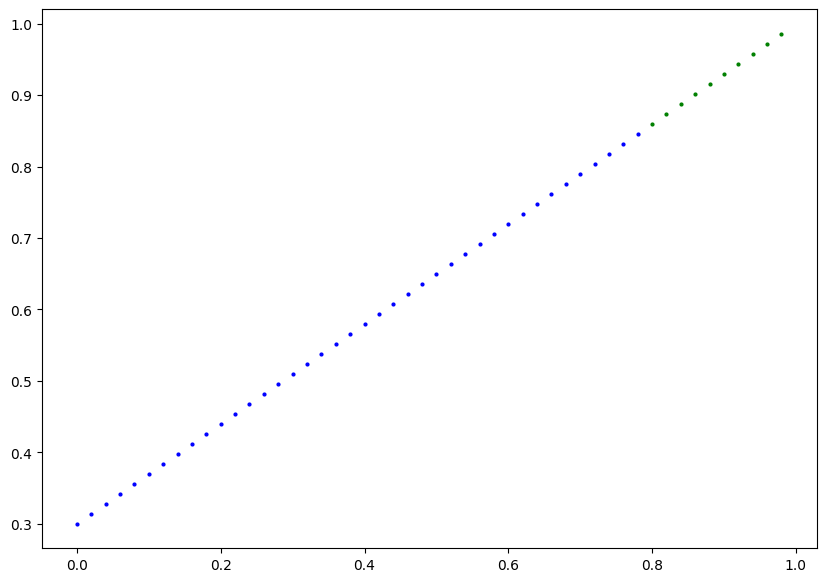

In [15]:
plot_predictions();

## 2. Construir o modelo

Nosso primiero modelo PyTorch

O que nosso modelo faz:
* Começa com valores aleatórios(weight e bias)
* Olha os dados de treinamento e ajusta os valores aleatórios para representar melhor (ou chegar mais perto) os valores ideais ( o weight e o bias nós usamos para criar os dados)

Como ele faz isso?

Por meio de dois algoritmos principais:
1. Descida do Gradiente
2. Backpropagation

In [16]:
from torch import nn

# Crie uma classe de modelo de regressão linear
class LinearRegressionModel(nn.Module): # <- quase tudo no PyTorch herda de nn.Module
    def __init__(self):
        super().__init__() # Chama o construtor da classe pai, para ja criar os dicionarios weights e bias
        self.weights = nn.Parameter(torch.randn(1, # <- começa com um numero aleatorio do peso e tenta ajustar para o peso ideal
                                                requires_grad = True, # <- esse parametro pode ser atualizado pela descida do gradiente?
                                                dtype = torch.float)) # <- PyTorch ama o datatype toch.float32
        self.bias = nn.Parameter(torch.randn(1, # <- começa com um bias aleatorio e tenta ajustar ele ao bias ideal
                                            requires_grad = True, # <- esse parametro pode ser atualizado pela descida do gradiente?
                                            dtype = torch.float)) # <- PyTorch ama o datatype toch.float32
        
        # Método Forward para definir o cálculo no modelo
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" são os dados de entrada, x: torch.Tensor espera que a entrada seja um tensor e -> torch.Tensor espera que a saída seja um Tensor
        return self.weights * x + self.bias # Essa é a fórmula da regressão linear


In [18]:
model_0 = LinearRegressionModel()
model_0.state_dict()

OrderedDict([('weights', tensor([0.3402])), ('bias', tensor([0.5137]))])

### Itens essenciais de construção de modelos do PyTorch

* torch.nn - contem todos os blocos de construção de grafos computacionais(uma rede neural pode ser considerada um grafo computacional)
* torch.nn.Parameter - Quais parametros nosso modelo deve tentar e aprender, frequentemente uma camada PyTorch de torch.nn define isso para nós
* torch.nn.Module - A classe base para todos os nossos módulos de rede neural, se voce esta com a subclasse, deve sobrescrever forward()
* torch.optim - é aqui que os otimizaores do PyTorch vivem, eles ajudarão na descida do gradiente
* def forward() - todas as subclasses de nn.Module exigem que voce sobrescreva forward, ese método define o que acontece no cálculo forward

### Checando o conteudo do nosso modelo PyTorch

Agora criamos um modelo, vamos ver o que tem dentro..

Podemos verificar os parametros do nosso modelo ou o que esta dentro dele usando `.parameters() `.

In [63]:
# Listar os parametros nomeados
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Fazendo previsões usando `torch.inference_mode()`

Para verificar a capacidade de previsão do nosso modelo, vamos ver o quão bem ele prevê `y_test`  com base no `X_test`.

Quando passarmos os dados pelo nosso modelo, ele sera executado pelo método forward

In [64]:
y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [65]:
# Fazer previsões com o modelo
with torch.inference_mode():
    y_preds = model_0(X_test)


# Pode-se fazer algo semelhante com o torch.no_grad(), mas torch.inference_mode() é preferido
#with torch.no_grad():
    #y_preds = model_0(X_test)


y_preds    


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [66]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

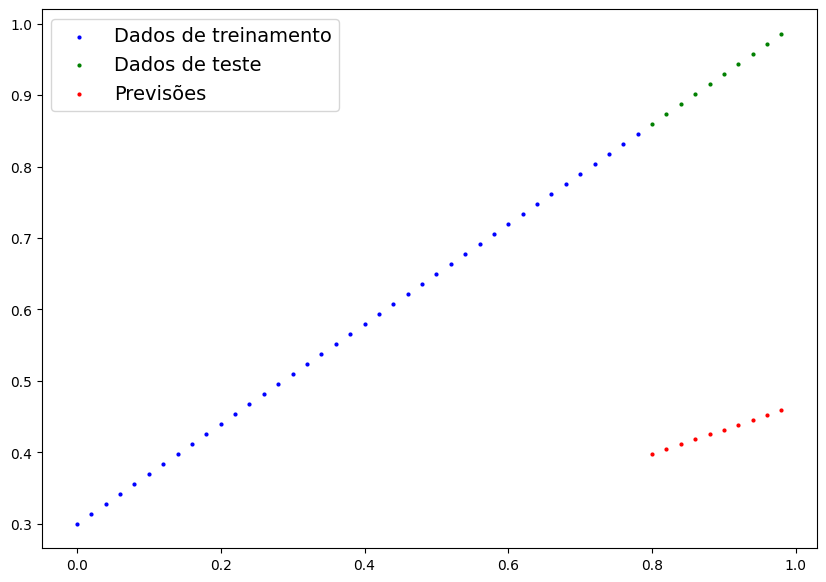

In [67]:
plot_predictions(predictions = y_preds)

## 3. Treinando o modelo

A ideia geral do treinamento é que um modelo se mova a partir de alguns parâmetros *desconhecidos* (esses podem ser aleatórios) para alguns paramêtros *conhecidos*

Ou em outras palavras de uma pior representação dos dados a uma melhor representação dos dados.

Uma maneira de medir quão ruins ou quão erradas estao as previsões do seu modelo é usar uma função de perda(Loss Function)

* Nota: Funçao de perda pode ser chamada função de custo(cost function) ou criterio em diferentes áreas. Em nosso caso, vamos nos referir a isso como função de perda.

Coisas que precisamos treinar:

* **Loss Function:** é uma função para medir o quanto as previsões de seu modelo estão erradas em relação aos resultados, quanto menor melhor.
* **Optimizador:** Leva em conta a perda de um modelo e ajusta os parâmetros do modelo(pesos e vieses no nosso caso) para melhorar a funçao de perda.
 - Dentro do otimizador temos dois parâmetros:
     - `params`- os parametros do modelo que voce deseja otimizar, por exemplo `params = model_o.parameters()`
     - `lr`(learning rate)- a taxa de aprendizado é um hiperparâmetro que define quão grande/pequeno o otimizador mudar os parâmetros a cada passo( um pequeno lr resulta em uma pequena mudança, um grande lr resulta em uma grande mudança)

E especificamente para o PyTorch, nós precisamos de: 
* Um looping de treinamento
* Um looping de teste


In [68]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [69]:
# Checando os parâmetros do nosso modelo( um parÂmetro é um valor que o próprio modelo define)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [70]:
# Configurar uma função de perda
loss_fn = nn.L1Loss()

# Configurar um otimizador (descida do gradiente estocastica)
optimizer =  torch.optim.SGD(params = model_0.parameters(), lr = 0.01) # lr = possivelmente o hiperparâmetro de aprendizado mais importante que voce pode definir

**P**: Qual função de perda e otimizador devo usar?

**R**: Isso depende do problema. Mas com experiência voce tera uma ideia do que funciona e o que não funciona para o seu problema em particular

Por exemplo, para um problema de regressão linear(como o nosso), a loss function de `nn.L1Loss` e o otimizador `torch.optim.SGD()`são suficientes.

Mas para um problema de classificação, como classificar qual foto é de um cachorro ou gato, voce provavelmente usaria a loss funcion  `nn.BCELoss()` (Entropia cruzada binária ).

### Construindo um loop de treinamento(e loop de teste) em PyTorch

Algumas coisas que fizemos no loop de treinamento:
0. Loop por meio dos dados e faça...
1. Forward pass ( isso envolve a movimentação dos dados em nossas funções `forward()`) para fazer previsões nos dados - também chamado de Forward Propagation
2. Calcular a perda (comparar as previsões forward pass com os verdadeiros rótulos)
3. Otimizador zero grad
4. Loss Backward - mover-se para trás na rede para calcular os gradientes de cada um dos parâmetros do nosso modelo com relação à perda(**backpropagation**)
5. Otimizador - isso usará o otimizador para ajustar os parâmetros de nossos modelos para melhorar a perda(**gradient descent**)

In [71]:
torch.manual_seed(42)

# Epócas são um loop pelos dados... ( isso é um hiperparâmetro por que nós mesmos definimos)
epochs = 200

epoch_count = []
loss_values = []
test_loss_values = []

### Treinando
# 0. Percorrer os dados em loop
for epoch in range(epochs):
    # coloca o modelo em modo treinamento (ativa Dropout/BatchNorm)
    model_0.train()
    
    #1. Forward pass(Previsão)
    y_pred = model_0(X_train)

    # 2. Calcular a perda de treino
    loss = loss_fn(y_pred, y_train)

    # 3. zerar os gradientes
    optimizer.zero_grad()

    # 4. Executa backpropagation sobre a perda com relação aos parâmetros do modelo
    loss.backward()

    # 5. Otimizador (executa a descida do gradiente)
    optimizer.step() # Por default , essas alterações do otimizador serâo acumuladas através do loop entao temos que zerá-los acima, na etapa 3 para a próxima iteração do loop


    ### Teste
    model_0.eval() # desativa diferetes configurações no modelo que não são necessárias para avaliação/teste (dropout/batch normalization)
    with torch.inference_mode(): #desativa o rastreamento de gradientes e mais algumas coisas nos bastidores
        # with torch.no_grad(): # Voce pode talvez ver torch.no_grad em codigos PyTorch mais antigos
        # 1. fazer o forward pass(previsões)
        test_pred = model_0(X_test)

        #2. Calcular a perda
        test_loss = loss_fn(test_pred, y_test)
    # Printar o que esta acontecendo
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"época: {epoch} | Perda: {loss} | test loss: {test_loss} ")
        print(model_0.state_dict())

época: 0 | Perda: 0.31288138031959534 | test loss: 0.48106518387794495 
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
época: 10 | Perda: 0.1976713240146637 | test loss: 0.3463551998138428 
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
época: 20 | Perda: 0.08908725529909134 | test loss: 0.21729660034179688 
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
época: 30 | Perda: 0.053148526698350906 | test loss: 0.14464017748832703 
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
época: 40 | Perda: 0.04543796554207802 | test loss: 0.11360953003168106 
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
época: 50 | Perda: 0.04167863354086876 | test loss: 0.09919948130846024 
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
época: 60 | Perda: 0.03818932920694351 | test loss: 0.08886633068323135 
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
época: 7

In [86]:
import numpy as np
loss_values = torch.Tensor(loss_values).numpy()
test_loss_values = torch.Tensor(test_loss_values).numpy()

loss_values, test_loss_values

(array([0.31288138, 0.19767132, 0.08908726, 0.05314853, 0.04543797,
        0.04167863, 0.03818933, 0.0347609 , 0.03132383, 0.0278874 ,
        0.02445896, 0.02102021, 0.01758547, 0.01415539, 0.01071659,
        0.00728353, 0.00385178, 0.00893248, 0.00893248, 0.00893248],
       dtype=float32),
 array([0.48106518, 0.3463552 , 0.2172966 , 0.14464018, 0.11360953,
        0.09919948, 0.08886633, 0.08059376, 0.07232123, 0.06473556,
        0.05646304, 0.0481905 , 0.04060482, 0.03233228, 0.02405975,
        0.01647409, 0.00820156, 0.00502309, 0.00502309, 0.00502309],
       dtype=float32))

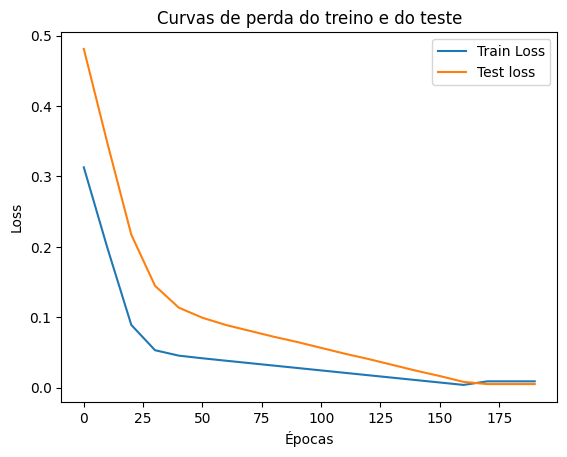

In [87]:
# plot das curvas de perda
plt.plot(epoch_count, loss_values, label = "Train Loss")
plt.plot(epoch_count, test_loss_values, label = "Test loss")
plt.title("Curvas de perda do treino e do teste")
plt.ylabel("Loss")
plt.xlabel("Épocas")
plt.legend()

In [72]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

In [73]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [74]:
weight, bias

(0.7, 0.3)

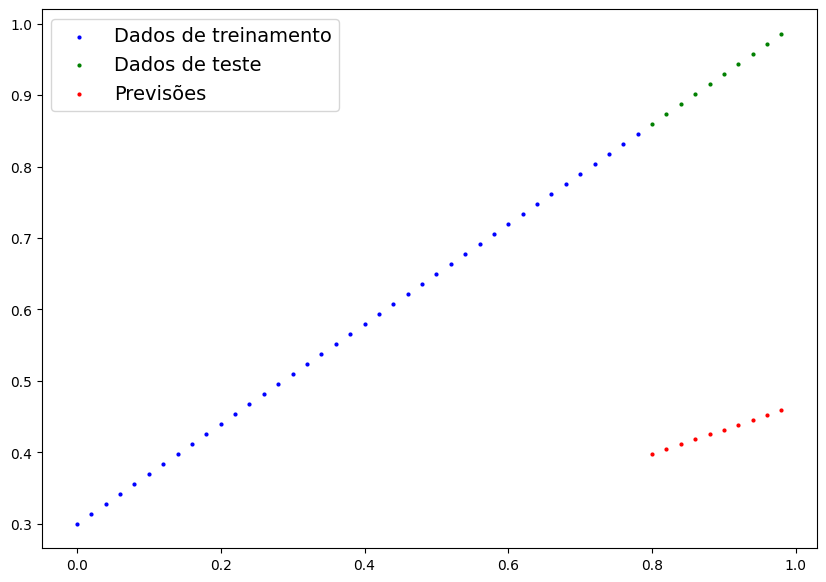

In [75]:
plot_predictions(predictions = y_preds)

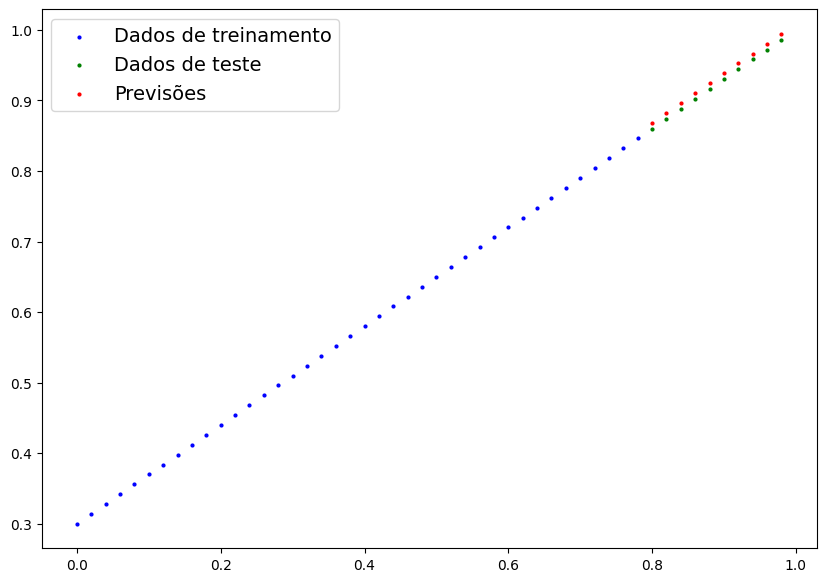

In [76]:
plot_predictions(predictions = y_preds_new)

 ## Salvando um modelo em PyTorch

 Há três métodos principais que devemos saber sobre para salvar e carregar os modelos em PyTorch.

 1. `torch.save()` - permite que voce salve um objeto PyTorch em Python no formato pickle
 2. `torch.load()`- permite carregar um objeto PyTorch salvo
 3. `torch.nn.Module.load_state_dict()` - isso permite que voce carregue um state dictionary salvo de um modelo

In [92]:
# Salvando nosso modelo PyTorch
from pathlib import Path

# 1. Crie um diretório de modelos
MODEL_PATH = Path("modelos")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

# 2. Criar um caminho para salvar o modelo
MODEL_NAME = "01_Pytorch_workflow_model_0.pth" 
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Salvar o state dict do modelo
print(f"Salvando o modelo em: {MODEL_SAVE_PATH}")
torch.save(obj = model_0.state_dict(),f =  MODEL_SAVE_PATH)

Salvando o modelo em: modelos/01_Pytorch_workflow_model_0.pth


In [94]:
!ls -l modelos

total 4
-rw-rw-r-- 1 lucas lucas 2117 jun  5 23:10 01_Pytorch_workflow_model_0.pth


## Carregando um modelo PyTorch

Já que salvamos o `state_dict()` do nosso modelo  ao invés do modelo inteiro, criaremos uma nova instancia da nossa classe de modelo e carregaremos o `state_dict()` salvo

In [95]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [99]:
# Para carregar o nosso modelo, intanciamos uma nova classe
loaded_model_0 = LinearRegressionModel()

# Carregamos o state_dict salvo de model_0(isso atualizará a nova instância com parâmetros atualizados)
loaded_model_0.load_state_dict(torch.load(f = MODEL_SAVE_PATH))

<All keys matched successfully>

In [100]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [102]:
# Fazendo algumas previsões com nosso modelo carregado
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds


tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [103]:
# Comparar as previsões do modelo carregado com as previsões do modelo original
loaded_model_preds == y_preds_new

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 6. Juntando tudo isso

Vamos voltar às etapas acima e ver tudo em um só lugar.

In [1]:
# Importando PyTorch e matplotlib
import torch 
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.12.0+cu130'

Criando um código independente de dispositivo.

Isso significa se tivermos acesso a GPU, nosso código a usará(paara uma potencial computação mais rápida).

Se não houver GPU disponível, o código terá como padrão o uso da CPU.

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device}")

cpu


### 6.1 Dados

In [3]:
# Criar algun sdados usando a fórmula de regressão linear y = weight * X + bias
weight = 0.5
bias = 0.1

# Criando valores em um intervalo
start = 0
end = 1
step = 0.02
# Criar X e y(features e labels)
X = torch.arange(start,end,step).unsqueeze(dim = 1) # Sem unsqueeze erros aparecerão
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.1000],
         [0.1100],
         [0.1200],
         [0.1300],
         [0.1400],
         [0.1500],
         [0.1600],
         [0.1700],
         [0.1800],
         [0.1900]]))

In [4]:
# Dividindo os dados
div_train = int(0.8 * len(X))
X_train, y_train = X[:div_train], y[:div_train]
X_test, y_test = X[div_train:], y[div_train:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

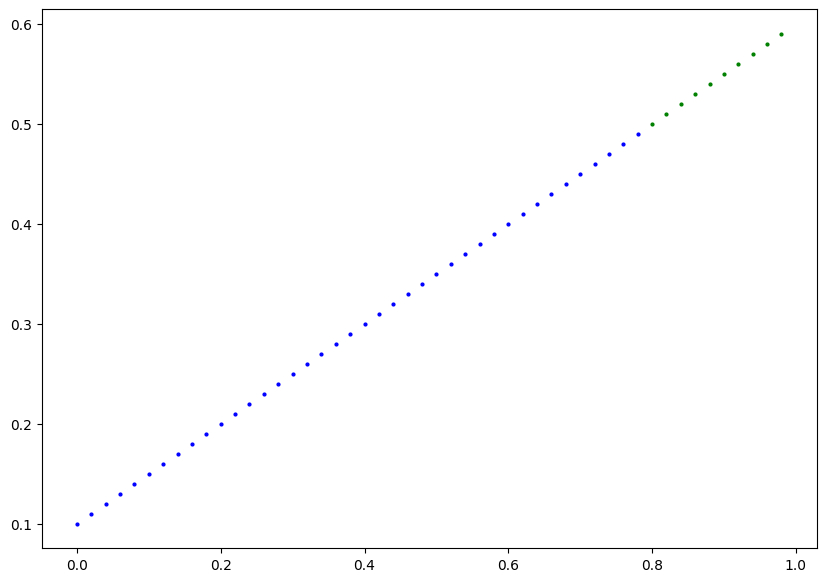

In [7]:
# Plotando os dados
# NOte: Se você não tiver a função plot_predictions() carregada , isso resultará em erro
plot_predictions(X_train, y_train, X_test, y_test)


## 6.2 Construindo um modelo linear PyTorch

In [8]:
# Criar um modelo linear por meio de umas subclasses de nn.Module
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Usaremos nn.Linear() para criar os parâmetros do modelo / também chamado de transformação linear, probing layer, fully connected layer, dense layer
        self.linear_layer = nn.Linear(in_features = 1,
                                      out_features = 1)
 
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)
    
# Definir a manual_seed para que tenhamos reprodutibilidade    
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [9]:
# Checar o dispositivo atual do modelo
next(model_1.parameters()).device

device(type='cpu')

In [10]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cpu')

In [11]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

### 6.3 Treinamento

Para treinamento nós precisamos:
* Loss function
* Otimizador
* Loop de treinamento
* Loop de teste


In [12]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model_1.parameters(), lr = 0.01)

In [13]:
torch.manual_seed(42)

epocas = 200

# Colocar os dados no dispositivo de destino(device agnostic code for data)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

X_train = X_train.detach()
y_train = y_train.detach()
for epoca in range(epocas):
    model_1.train()

    y_pred = model_1(X_train)
    loss= loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        loss_test = loss_fn(test_pred, y_test)

    if epoca % 10 == 0:
        print(f"Epoca: {epoca} | Loss: {loss.item()} | Test Loss: {loss_test.item()}")

Epoca: 0 | Loss: 0.833177924156189 | Test Loss: 0.9519761800765991
Epoca: 10 | Loss: 0.7179681062698364 | Test Loss: 0.8172663450241089
Epoca: 20 | Loss: 0.6027581095695496 | Test Loss: 0.6825565695762634
Epoca: 30 | Loss: 0.487548291683197 | Test Loss: 0.5478467345237732
Epoca: 40 | Loss: 0.3723384439945221 | Test Loss: 0.41313689947128296
Epoca: 50 | Loss: 0.2571285367012024 | Test Loss: 0.2784270644187927
Epoca: 60 | Loss: 0.14191867411136627 | Test Loss: 0.1437171995639801
Epoca: 70 | Loss: 0.026708656921982765 | Test Loss: 0.00900720339268446
Epoca: 80 | Loss: 0.005493368022143841 | Test Loss: 0.011843070387840271
Epoca: 90 | Loss: 0.005493368022143841 | Test Loss: 0.011843070387840271
Epoca: 100 | Loss: 0.005493368022143841 | Test Loss: 0.011843070387840271
Epoca: 110 | Loss: 0.005493368022143841 | Test Loss: 0.011843070387840271
Epoca: 120 | Loss: 0.005493368022143841 | Test Loss: 0.011843070387840271
Epoca: 130 | Loss: 0.005493368022143841 | Test Loss: 0.011843070387840271
Epoc

In [14]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.4923]])),
             ('linear_layer.bias', tensor([0.1085]))])

In [15]:
weight, bias

(0.5, 0.1)

### 6.4 Fazendo e avaliando previsões 

In [16]:
# Colocar o modelo no modo de avaliação
model_1.eval()

# Fazendo previsões nos dados de teste
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds    

tensor([[0.5023],
        [0.5122],
        [0.5220],
        [0.5319],
        [0.5417],
        [0.5516],
        [0.5614],
        [0.5712],
        [0.5811],
        [0.5909]])

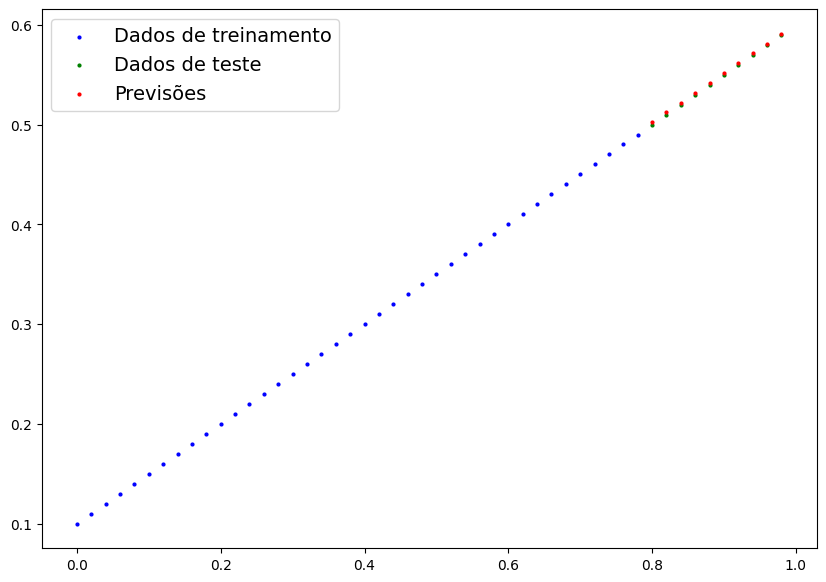

In [17]:
# Checar as previsões do nosso modelo visualmente
plot_predictions(predictions = y_preds)


### 6.5 Salvando e carregando um modelo treinado 

In [21]:
from pathlib import Path

# 1. Criar diretório de modelos
MODEL_PATH = Path("modelos")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

# 2. Criar um caminho para salvar o modelo
MODEL_NAME = "01_Pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Salvar o state dict do modelo
print(f"Salvando modelo em: {MODEL_SAVE_PATH}")
torch.save(obj = model_1.state_dict(), f = MODEL_SAVE_PATH)




Salvando modelo em: modelos/01_Pytorch_workflow_model_1.pth


In [19]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.4923]])),
             ('linear_layer.bias', tensor([0.1085]))])

In [22]:
# Carregar um modelo PyTorch

# Criamos uma nova instância do modelo de regressão linear V2
loaded_model_1 = LinearRegressionModelV2()

# Carregar o state dict do model_1 salvo
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))


# Colocar o modelo carregado  no dispositivo
loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
next(loaded_model_1.parameters()).device

device(type='cpu')

In [27]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.4923]])),
             ('linear_layer.bias', tensor([0.1085]))])

In [28]:
# Avaliar o modelo carregado
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## Exercicios e Extra-curricular

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"


In [3]:
weight = 0.3
bias = 0.9
start = 0
end = 2
step = 0.01
X = torch.arange(start,end, step).unsqueeze(dim = 1)
y = weight * X + bias
len(X), len(y)

(200, 200)

In [4]:
divisao_treino = int(0.8 * len(X))
X_treino, y_treino = X[:divisao_treino], y[:divisao_treino]
X_teste, y_teste = X[divisao_treino:], y[divisao_treino:]

len(X_treino), len(y_treino), len(X_teste), len(y_teste)

(160, 160, 40, 40)

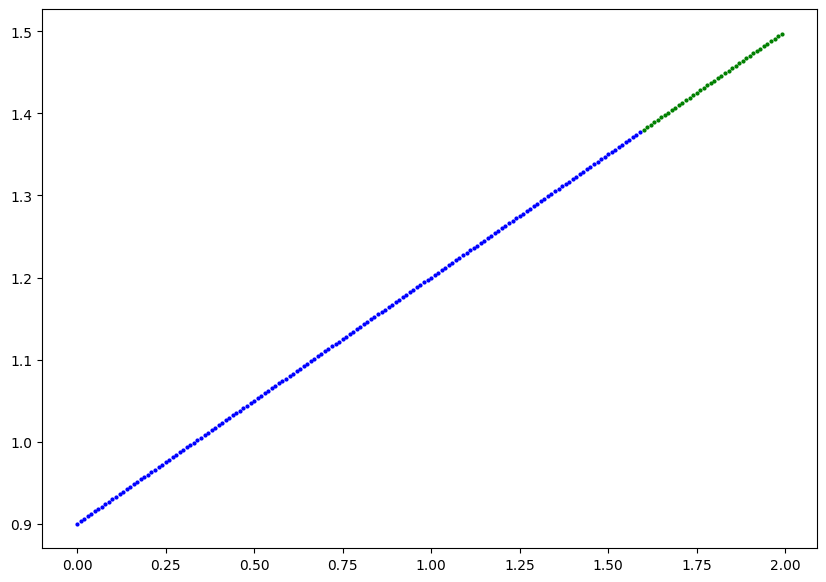

In [5]:
plt.figure(figsize = (10,7))
plt.scatter(X_treino, y_treino, c = "b", s = 4 , label = "Dados de treinamento")
plt.scatter(X_teste, y_teste, c = "g", s = 4, label = "Dados de teste")

In [6]:
class LinearRegressionModelV3(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(in_features= 1,
                                out_features=1)
        
    def forward(self,x:torch.Tensor)->torch.Tensor:
        return self.linear(x)    

In [7]:
model_2 = LinearRegressionModelV3()
model_2.state_dict()

OrderedDict([('linear.weight', tensor([[0.9545]])),
             ('linear.bias', tensor([0.0826]))])

In [8]:
funcao_perda = nn.L1Loss()

otimizador = torch.optim.SGD

In [9]:
otimizador = otimizador(params = model_2.parameters(), lr = 0.001)

In [18]:
epocas = 30000
for epoca in range(epocas):
    y_previsoes_treino = model_2(X_treino)
    perda_treino = funcao_perda(y_previsoes_treino, y_treino)
    otimizador.zero_grad()
    perda_treino.backward()
    otimizador.step()

    model_2.eval()
    with torch.inference_mode():
        y_previsoes_teste = model_2(X_teste)
        perda_teste = funcao_perda(y_previsoes_teste, y_teste)

    if epoca % 20 == 0:
        print(f"época: {epoca} | Perda no treino: {perda_treino} | Perda no teste: {perda_teste}")


época: 0 | Perda no treino: 0.015168559737503529 | Perda no teste: 0.030180955305695534
época: 20 | Perda no treino: 0.013358714990317822 | Perda no teste: 0.026562700048089027
época: 40 | Perda no treino: 0.011548980139195919 | Perda no teste: 0.02292739227414131
época: 60 | Perda no treino: 0.009739186614751816 | Perda no teste: 0.019326146692037582
época: 80 | Perda no treino: 0.007929443381726742 | Perda no teste: 0.01569082774221897
época: 100 | Perda no treino: 0.006119645666331053 | Perda no teste: 0.012055513449013233
época: 120 | Perda no treino: 0.004309860989451408 | Perda no teste: 0.00845426321029663
época: 140 | Perda no treino: 0.0025001198519021273 | Perda no teste: 0.004818952176719904
época: 160 | Perda no treino: 0.0006903245812281966 | Perda no teste: 0.0011835992336273193
época: 180 | Perda no treino: 0.00122336414642632 | Perda no teste: 0.0007966548437252641
época: 200 | Perda no treino: 0.00122336414642632 | Perda no teste: 0.0007966548437252641
época: 220 | Per

In [19]:
model_2.eval()
with torch.inference_mode():
    y_previsoes_model_2 = model_2(X_teste)

    

In [20]:
y_previsoes_model_2[:5],y_teste[:5]

(tensor([[1.3784],
         [1.3814],
         [1.3844],
         [1.3874],
         [1.3904]]),
 tensor([[1.3800],
         [1.3830],
         [1.3860],
         [1.3890],
         [1.3920]]))

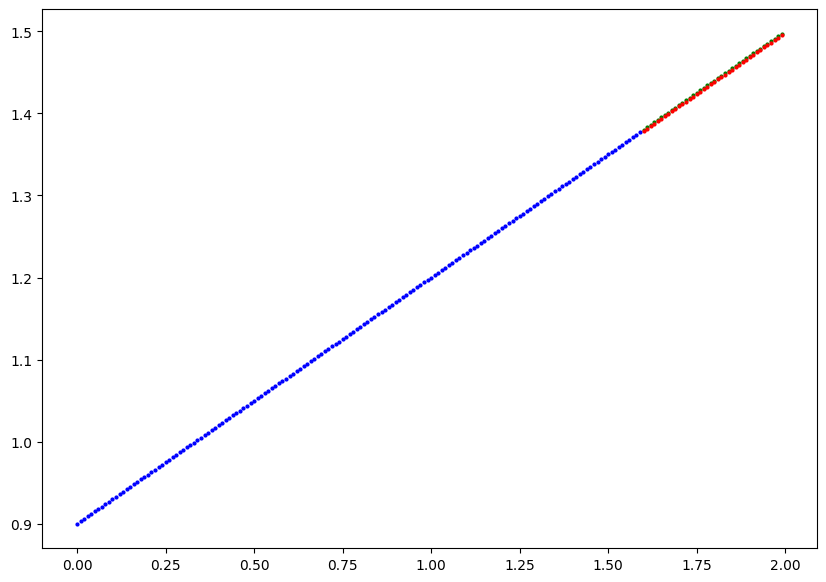

In [21]:
plt.figure(figsize = (10,7))
plt.scatter(X_treino, y_treino, c = "b", s = 4 , label = "Dados de treinamento")
plt.scatter(X_teste, y_teste, c = "g", s = 4, label = "Dados de teste")
plt.scatter(X_teste, y_previsoes_model_2, c = "r", s = 4, label = "Previsões do modelo")

In [29]:
from pathlib import Path

CAMINHO_MODELO = Path("modelos")
CAMINHO_MODELO.mkdir(parents = True, exist_ok = True)

NOME_MODELO = "01_Pytorch_workflow_model_2.pth"
CAMINHO_SALVO_MODELO = CAMINHO_MODELO / NOME_MODELO

print(f"Salvando modelo em: {CAMINHO_SALVO_MODELO}")
torch.save(obj = model_2.state_dict(), f = CAMINHO_SALVO_MODELO)

Salvando modelo em: modelos/01_Pytorch_workflow_model_2.pth


In [37]:
loaded_model_2 = LinearRegressionModelV3()
loaded_model_2.load_state_dict(torch.load(CAMINHO_SALVO_MODELO))
y_preds_loaded = loaded_model_2(X_teste)
y_preds_loaded == y_previsoes_model_2

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

# 02 Classificação em redes neurais com Pytorch 

Classificação é um problema de prever se algo é uma coisa ou outra(pode ter varias coisas como opções)

## 1. Criar alguns dados de classificação e deixá-lo prontos

In [18]:
import sklearn

In [19]:
from sklearn.datasets import make_circles

# Criar 1000 amostras
n_amostras = 1000

# Criar circulos
X, y = make_circles(n_amostras,
                    noise = 0.03,
                    random_state=42)

In [20]:
len(X), len(y)

(1000, 1000)

In [21]:
print(f"Primeiras 5 amostras de X:{X[:5]}")
print(f"Primeiras 5 amostras de y:{ y[:5]}")


Primeiras 5 amostras de X:[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
Primeiras 5 amostras de y:[1 1 1 1 0]


In [22]:
y

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [23]:
# Criar um DataFrame de dados circulares com Pandas
import pandas as pd
circulos = pd.DataFrame({"X1": X[:, 0], 
                         "X2": X[:,1],
                         "label": y})

circulos.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


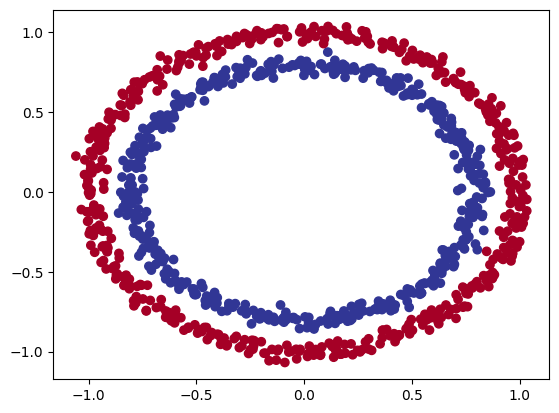

In [24]:
# visualize, visualize, visualize
import matplotlib.pyplot as plt
plt.scatter(x = X[:,0],
            y = X[:,1],
            c = y,
            cmap = plt.cm.RdYlBu)

**Nota:** Os dados que estamos trabalhando são frequentemente mencionados como um conjunto de dados de brinquedo(toy dataset), um dataset que seja pequeno o suficiente para ser experimentado, mas grande o suficiente para praticar os fundamentos

### 1.1  Checar formatos (shapes) de entrada e saída

In [25]:
X.shape, y.shape

((1000, 2), (1000,))

In [26]:
# Veja o primeiro exemplo de features e labels
X_sample = X[0]
y_sample = y[0]
X_sample, y_sample

print(f"Valores para ua amostra de X: {X_sample} e o mesmo para y: {y_sample}")
print(f"Shape de uma amostra de X: {X_sample.shape}, o mesmo para y: {y_sample.shape}")

Valores para ua amostra de X: [0.75424625 0.23148074] e o mesmo para y: 1
Shape de uma amostra de X: (2,), o mesmo para y: ()


### 1.2 Transformando dados em tensores e criar divisões de treino e teste

In [27]:
import torch
torch.__version__

'2.12.0+cu130'

In [28]:
type(X)

numpy.ndarray

In [29]:
# Tranformar dados em tensores
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]


(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [30]:
type(X), type(y), X.dtype, y.dtype

(torch.Tensor, torch.Tensor, torch.float32, torch.float32)

In [31]:
# Separar dados em conjuntos de treinamento e teste
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(X,
                                                        y,
                                                        test_size=0.2,
                                                        random_state = 42)


In [32]:
len(X_treino), len(X_teste), len(y_treino), len(y_teste)

(800, 200, 800, 200)

## 2 Construindo um modelo

Vamos construir um modelo para classificar nossos pontos azuis e vermelhos.

Para isso, nós queremos:
1. Configurar o código agnóstico do dispositivo, portanto nosso codigo dera executado em um acelerador(GPU) se houver uma, se não houver será executado na CPU
2. Construir o modelo(pela subclasse `nn.Module`)
3. Definir a função de perda e o otimizador
4. Criar um loops de treinamento e de teste



In [33]:
import torch
from torch import nn

# Fazer o código agnóstico
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [34]:
X_treino

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

Agora nós temos o código agnóstico de dispositivo configurado, vamos criar um modelo que:

1. Subclasse de `nn.Module`(quase todos os modelos são da subclasse Pytorch `nn.Module`)
2. Criar 2 camadas `nn.Linear()` e queremos que eles sejam capazes de lidar com os formatos dos nossos dados
3. Definir o método `forward()` que delimita o forward pass(ou forward computation) do modelo
4. Instanciar uma instância da nossa classe do modelo e envia-la para o `dispositivo` alvo



In [35]:
X_treino.shape

torch.Size([800, 2])

In [36]:
# 1. Construir um modelo com a subclasse nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Criar duas camadas nn.Linear capazes de manipular as formas dos nossos dados
        self.layer_1 = nn.Linear(in_features = 2, out_features = 5) # pega duas entradas e transforma em cinco saídas
        self.layer_2 = nn.Linear(in_features = 5, out_features = 1) # recebe 5 saídas da camada anterior e transforma em uma saída(mesmo formato de y)

    # 3. Definindo o método forward
    def forward(self, x):
        return self.layer_2(self.layer_1(x)) # x -> layer_1 -> layer_2 -> saída
    

# 4. Instanciar uma classe do nosso modelo e enviá-la para o dispositivo de destino
model_1_0 = CircleModelV0().to(device)
model_1_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [37]:
device

'cpu'

In [38]:
next(model_1_0.parameters()).device

device(type='cpu')

In [40]:
# Vamos replicar o modelo acima usando nn.Sequential()
model_1_0 = nn.Sequential(
    nn.Linear(in_features = 2, out_features = 5),
    nn.Linear(in_features= 5, out_features = 1)
).to(device)

model_1_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [41]:
model_1_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0996,  0.2247],
                      [-0.4672,  0.5765],
                      [ 0.2732, -0.1078],
                      [ 0.5277,  0.0794],
                      [ 0.4685,  0.5431]])),
             ('0.bias', tensor([-0.7000, -0.6432,  0.0700,  0.6339, -0.1913])),
             ('1.weight',
              tensor([[-0.0172,  0.2398, -0.3689,  0.1819, -0.2229]])),
             ('1.bias', tensor([-0.2120]))])

In [49]:
# Fazer algumas previsões com o modelo
with torch.inference_mode():
    untrained_preds = model_1_0(X_teste.to(device))
print(f"tamanho das previsões: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Tamanho das amostras de teste: {len(X_teste)}, Shape: {X_teste.shape}")
print(f"\nPrimeiras 10 previsões:\n{torch.round(untrained_preds[:10])}")
print(f"\n Primeiros 10 rótulos(labels):\n{y_teste[:10]}")


tamanho das previsões: 200, Shape: torch.Size([200, 1])
Tamanho das amostras de teste: 200, Shape: torch.Size([200, 2])

Primeiras 10 previsões:
tensor([[-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.]])

 Primeiros 10 rótulos(labels):
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [47]:
X_teste[:10] , y_teste[:10] 

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### 2.1 Configurar a função de perda e o otimizador

Qual função de perda ou otimizador deve-se usar?

De novo... isso é especifivo do problema.

Por exemplo para regressão você pode escolher o MAE ou MSE (mean absolute error or mean squared error).

Para classificação voce pode escolher a entropia cruzada binária(binary cross entropy) ou entropia cruzada categórica(cross entropy).

Como um lembrete, a função de perda mede o quanto as previsões do modelo estão **erradas**.

E para os otimizadores, dois dos mais comuns e úteis são o SGD e o Adam, no entanto pytorch tem muitas opções integradas.

* Para a função de perda, vamos usar `torch.nn.BCEWithLogitsLoss()`
* Para diferentes otimizadores ver `torch.optim()`

In [67]:
#loss_fn = nn.BCELoss() #BCELoss = requer que as entradas tenham passado pela função de ativação sigmoide antes de serem inseridas na BCELoss
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss tem a ativação sigmoide incorporada

otimizador = torch.optim.SGD(params = model_1_0.parameters(),
                             lr = 0.1
                             )

In [68]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/ len(y_pred)) * 100
    return acc

## 3. Treinamento de um modelo

Para treinar nosso modelo, precisaremos criar um loop de treinamento com as seguintes etapas:
1. Forward pass(inferencia)
2. Calcular a perda
3. Zerar os gradientes
4. Backpropagation
5. Otimizador(descida do gradiente)


### 3.1 Vamos passar de logits -> probabilidade de previsão -> previsão de rótulos

Os resultados de nosso modelo serão **logits**.

Podemos converter esses **logits** em **probabilidades de previsão** passando por eles para terem algum tipo de função de ativação(sigmoide para entropia cruzada binaria e softmax para clasificação multiclasse).

Então nós podemos converter as probabilidades de previsão do nosso modelo em **previsão de rótulos** arredondando-os ou usando `argmax()`.

In [58]:
# Veja as 5 primeiras saídas da inferência nos dados de teste
model_1_0.eval()
with torch.inference_mode():
    y_logits = model_1_0(X_teste.to(device))[:5]
y_logits

tensor([[-0.0936],
        [-0.1606],
        [-0.0891],
        [-0.0942],
        [-0.3607]])

In [59]:
y_teste[:5]

tensor([1., 0., 1., 0., 1.])

In [60]:
# Usar a funçao de ativação sigmóide em nosso modelo logits para transformá-los em probabilidades de previsão
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4766],
        [0.4599],
        [0.4777],
        [0.4765],
        [0.4108]])

Para nossos valores de probabilidade de previsão, precisamos realizar um arredondamento de range-style neles:
* `y_pred_probs` >= 0.5, `y=1` (classe 1)
* `y_pred_probs` < 0.5, `y=0` (classe 0)

In [ ]:
# Encontrando os rótulos previstos
y_preds = torch.round(y_pred_probs)

# Por completo(logits -> probabilidade das previsoes -> previsoes dos rótulos(labels))
y_pred_labels = torch.round(torch.sigmoid(model_1_0(X_teste.to(device))[:5]))

# Checar se há igualdade
print(torch.equal(y_preds.squeeze(), y_pred_labels.squeeze()))

# Fazer isso para se livrar da dimensão extra mais uma vez
y_preds.squeeze()

True


tensor([0., 0., 0., 0., 0.])

In [64]:
y_teste[:5]

tensor([1., 0., 1., 0., 1.])

### 3.2 Construindo loops de treinamento e teste

In [69]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Definir o número de épocas
epochs = 100

# Vamos colocar os dados no dispositivo de destino
X_treino, y_treino = X_treino.to(device), y_treino.to(device)
X_teste, y_teste = X_teste.to(device), y_teste.to(device)

# Criar nosso loop de treinamento e avaliação
for epoch in range(epochs):
    ### Treinamento
    model_1_0.train()

    # 1. Forward pass
    y_logits = model_1_0(X_treino).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # transformar logits -> probabilidades de previsão -> probabilidade de rótulos


    # 2. Calcular a perda/acurácia
    #loss = loss_fn(torch.sigmoid(y_logits), # nn.BCELoss espera probabilidades de previsão como entrada
    #               y_treino)
    loss = loss_fn(y_logits, # nn.BCEWithLogitsLoss espera logits brutos como entrada 
                   y_treino)
    acc = accuracy_fn(y_true = y_treino,
                      y_pred = y_pred)
    

    # 3. Otimizador zero grad
    otimizador.zero_grad()

    # 4. Loss backward(backpropagation)
    loss.backward()

    # 5. Etapa do otimizador(descida do gradiente)
    otimizador.step()

    ### Teste
    model_1_0.eval()
    with torch.inference_mode():
        # 1. Forward pass(inferência)
        test_logits = model_1_0(X_teste).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calcular a perda do teste/precisão
        test_loss = loss_fn(test_logits,
                            y_teste)
        test_acc = accuracy_fn(y_true = y_teste,
                            y_pred= test_pred)
    # Printar o que esta acontecendo
    if epoch % 10 == 0:
        print(f"Época: {epoch} | Perda: {loss:.5f} | Acc: {acc:.2f}% | Perda do teste: {test_loss:.5f} | Precisão no teste: {test_acc:.2f}%")







Época: 0 | Perda: 0.70219 | Acc: 46.12% | Perda do teste: 0.69975 | Precisão no teste: 44.00%
Época: 10 | Perda: 0.69622 | Acc: 47.12% | Perda do teste: 0.69475 | Precisão no teste: 46.00%
Época: 20 | Perda: 0.69461 | Acc: 49.12% | Perda do teste: 0.69352 | Precisão no teste: 48.00%
Época: 30 | Perda: 0.69407 | Acc: 49.62% | Perda do teste: 0.69326 | Precisão no teste: 48.50%
Época: 40 | Perda: 0.69382 | Acc: 50.50% | Perda do teste: 0.69325 | Precisão no teste: 49.00%
Época: 50 | Perda: 0.69366 | Acc: 50.38% | Perda do teste: 0.69331 | Precisão no teste: 50.50%
Época: 60 | Perda: 0.69354 | Acc: 49.62% | Perda do teste: 0.69339 | Precisão no teste: 51.50%
Época: 70 | Perda: 0.69345 | Acc: 49.25% | Perda do teste: 0.69348 | Precisão no teste: 55.50%
Época: 80 | Perda: 0.69337 | Acc: 50.00% | Perda do teste: 0.69357 | Precisão no teste: 54.00%
Época: 90 | Perda: 0.69330 | Acc: 49.88% | Perda do teste: 0.69366 | Precisão no teste: 53.50%
